<a href="https://colab.research.google.com/github/masum-mir/machine-learning-journey/blob/main/Weighted_KNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, precision_score,
    recall_score
)


In [97]:
# load data
df_raw = pd.read_csv("heart.csv")

display(df_raw.shape)
display(df_raw.head())

display(df_raw['target'].value_counts())


(1025, 14)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


,count
target,
1,526
0,499


Total rows: 1025
Duplicate rows: 723
Unique rows: 302


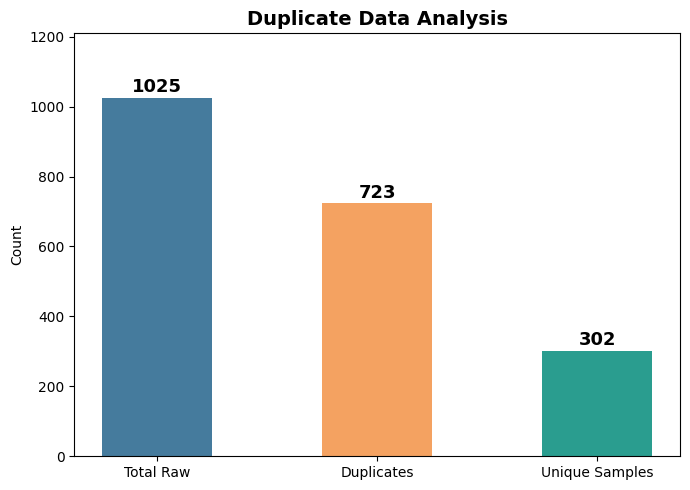


Missing Values: 


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [98]:
# Duplicate Analysis
n_raw = len(df_raw)
n_dups = df_raw.duplicated().sum()
df = df_raw.drop_duplicates().reset_index(drop=True)
n_clean = len(df)

print("Total rows:", n_raw)
print("Duplicate rows:", n_dups)
print("Unique rows:", len(df))

plt.figure(figsize=(7,5))

categories = ['Total Raw', 'Duplicates', 'Unique Samples']
values = [n_raw, n_dups, n_clean]
bar_colors = ["#457B9D", '#F4A261', "#2A9D8F"]
bars = plt.bar(categories, values, color=bar_colors, lw=1.5, width=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.title('Duplicate Data Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.ylim(0, max(values) * 1.18)
plt.tight_layout()
plt.savefig("DuplicateDATAAnalysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Missing Values
print("\nMissing Values: ")
display(df.isnull().sum())



In [99]:
# DESCRIPTIVE STATISTICS
print("Full Descriptive Statistics:")
display(df.describe().T.round(3))


Full Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.421,9.048,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682,0.466,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.964,1.032,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.603,17.563,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500,51.753,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149,0.357,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526,0.526,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.570,22.904,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.328,0.470,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043,1.161,0.0,0.00,0.8,1.60,6.2


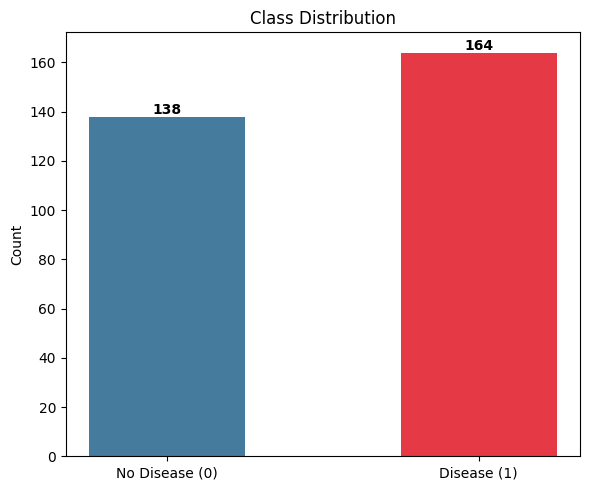

In [100]:
# CLASS DISTRIBUTION
counts = df['target'].value_counts().sort_index()
labels = ['No Disease (0)', 'Disease (1)']
colors = ["#457B9D", "#E63946"]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, counts.values, color=colors, width=0.5)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             str(val),
             ha='center', va='bottom', fontweight='bold')
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("ClassDistribution.png", dpi=300, bbox_inches='tight')
plt.show()

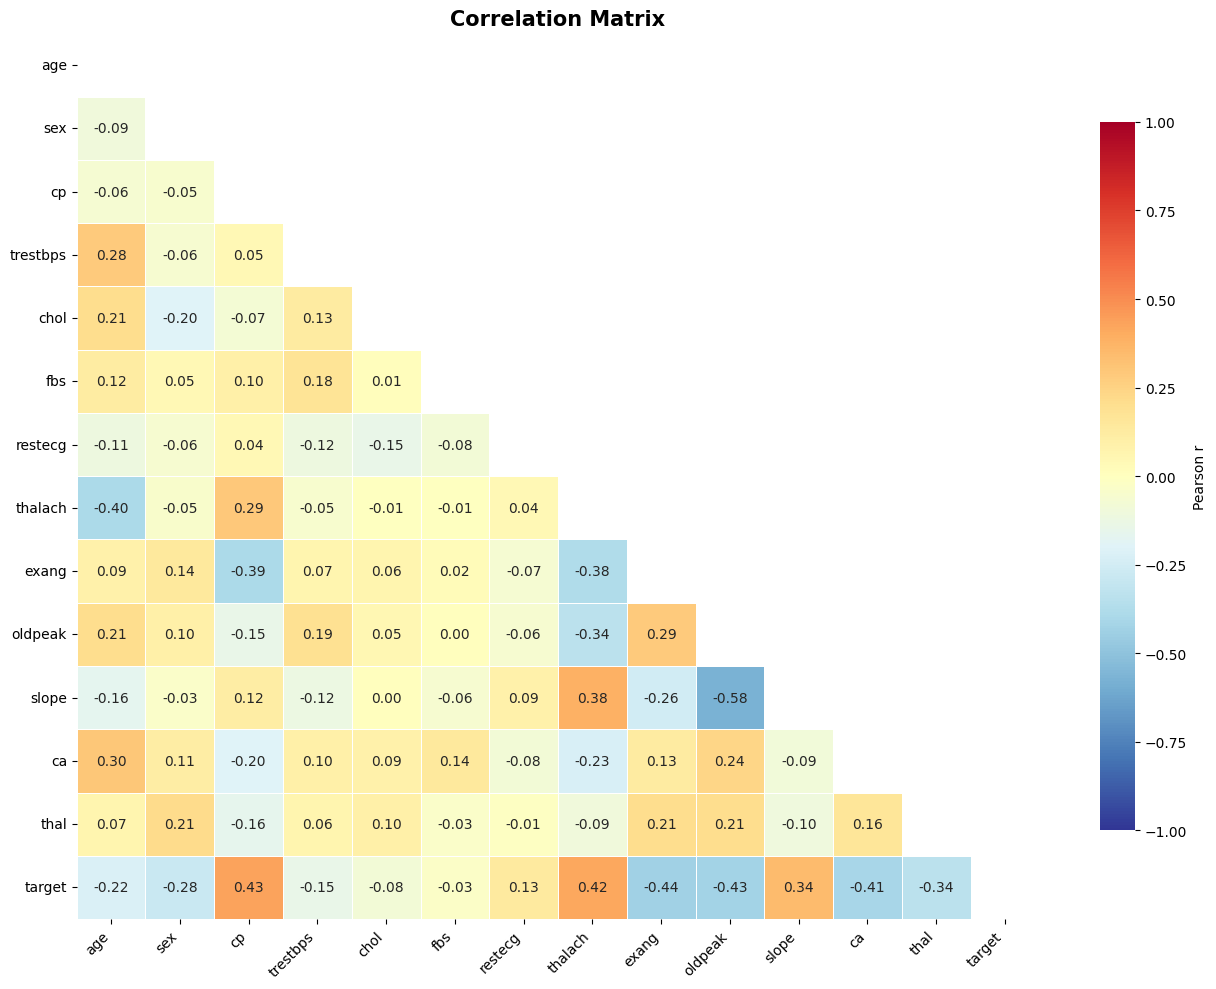

Top 10 Features Correlated with Target: 
exang       0.4356
cp          0.4321
oldpeak     0.4291
thalach     0.4200
ca          0.4090
slope       0.3439
thal        0.3431
sex         0.2836
age         0.2215
trestbps    0.1463
Name: target, dtype: float64


In [101]:
# CORRELATION ANALYSIS
fig, ax = plt.subplots(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax,
            vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
ax.set_title('Correlation Matrix', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("CorrelationMatrix.png", dpi=300, bbox_inches='tight')
plt.show()

# Top correlations with target
print("Top 10 Features Correlated with Target: ")
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print(target_corr.round(4).head(10))


In [102]:
# PREPROCESSING
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scaled_df = pd.DataFrame(X_train_sc, columns=X.columns)


In [103]:
k_range = range(1, 30)

cv_uniform = []
cv_distance = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV accuracy for each K
for k in k_range:
    # uniform weights (original)
    knn_u = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean')
    cv_uniform.append(cross_val_score(knn_u, X_train_sc, y_train, cv=skf, scoring='accuracy').mean())

    # distance weights (weighted KNN)
    knn_d = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    cv_distance.append(cross_val_score(knn_d, X_train_sc, y_train, cv=skf, scoring='accuracy').mean())

# to verify lengths
print(f"Length of k_range: {len(k_range)}")
print(f"Length of cv_uniform: {len(cv_uniform)}")
print(f"Length of cv_distance: {len(cv_distance)}")

best_k_uniform  = k_range[np.argmax(cv_uniform)]
best_k_distance = k_range[np.argmax(cv_distance)]

# Ensure 'best_k' is set for subsequent cells that might use it
best_k = best_k_uniform

print(f"Best K (uniform)  : {best_k_uniform}   | CV Acc: {max(cv_uniform):.4f}")
print(f"Best K (distance) : {best_k_distance}   | CV Acc: {max(cv_distance):.4f}")

Length of k_range: 29
Length of cv_uniform: 29
Length of cv_distance: 29
Best K (uniform)  : 21   | CV Acc: 0.8420
Best K (distance) : 7   | CV Acc: 0.8421


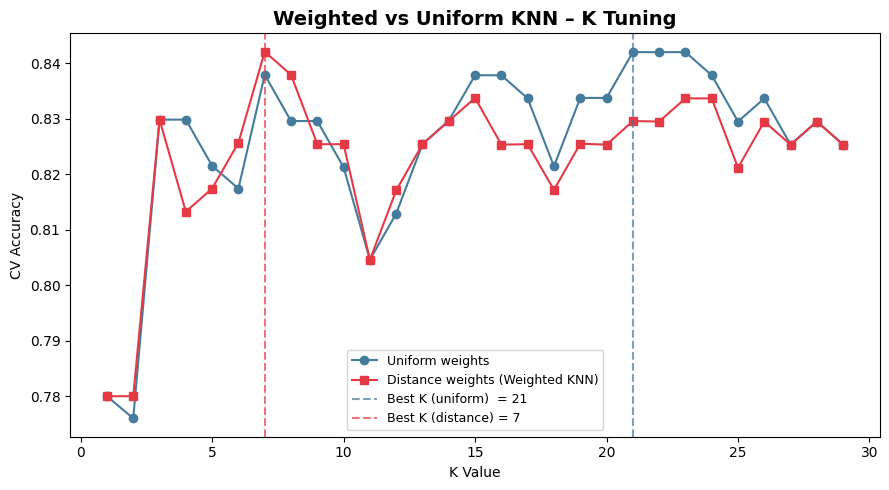

In [104]:
# K vs Accuracy: Uniform vs Weighted
plt.figure(figsize=(9, 5))

plt.plot(k_range, cv_uniform,  'o-', color='#457B9D', label='Uniform weights')
plt.plot(k_range, cv_distance, 's-', color='#E63946', label='Distance weights (Weighted KNN)')

plt.axvline(best_k_uniform,  color='#457B9D', linestyle='--', alpha=0.7,
            label=f'Best K (uniform)  = {best_k_uniform}')
plt.axvline(best_k_distance, color='#E63946', linestyle='--', alpha=0.7,
            label=f'Best K (distance) = {best_k_distance}')

plt.title('Weighted vs Uniform KNN – K Tuning', fontsize=14, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('CV Accuracy')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("WeightedKNN_Tuning.png", dpi=300, bbox_inches='tight')
plt.show()

In [105]:
# TRAIN FINAL KNN MODEL
# Uniform KNN
model_uniform = KNeighborsClassifier(n_neighbors=best_k, weights='uniform', metric='euclidean')
model_uniform.fit(X_train_sc, y_train)
y_pred_uniform = model_uniform.predict(X_test_sc)

# Weighted KNN
model_weighted = KNeighborsClassifier(n_neighbors=best_k_distance, weights='distance', metric='euclidean')
model_weighted.fit(X_train_sc, y_train)
y_pred_weighted = model_weighted.predict(X_test_sc)

print("Weighted KNN – Test Accuracy:", accuracy_score(y_test, y_pred_weighted))

Weighted KNN – Test Accuracy: 0.7868852459016393


In [106]:
# CLASSIFICATION METRICS
def get_metrics(y_true, y_pred, label):
    return {
        'Model'    : label,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1-Score' : f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_uniform,  f'KNN Uniform  (K={best_k})'),
    get_metrics(y_test, y_pred_weighted, f'KNN Weighted (K={best_k_distance})'),
])

print(results.set_index('Model').round(4).to_string())



                     Accuracy  Precision  Recall  F1-Score
Model                                                     
KNN Uniform  (K=21)    0.8525     0.8333  0.9091    0.8696
KNN Weighted (K=7)     0.7869     0.7778  0.8485    0.8116


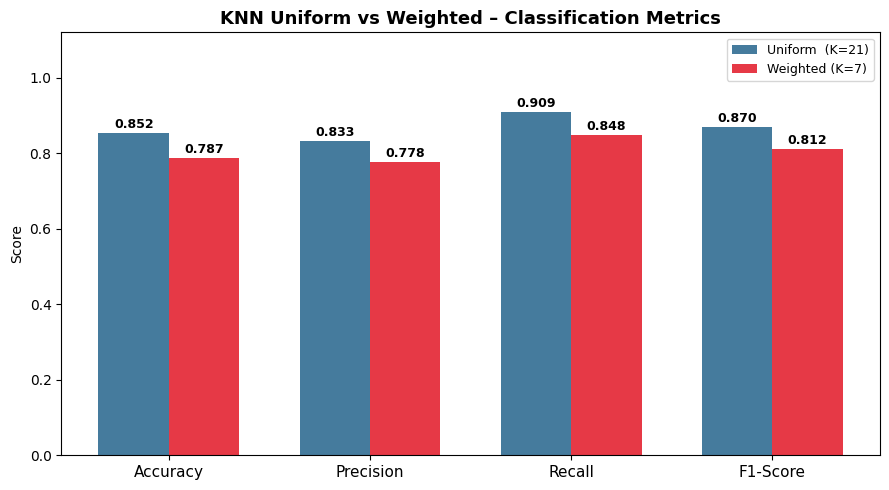

In [107]:
# BAR CHART – Metric Comparison
import numpy as np

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
uniform_vals  = [accuracy_score(y_test, y_pred_uniform),
                 precision_score(y_test, y_pred_uniform),
                 recall_score(y_test, y_pred_uniform),
                 f1_score(y_test, y_pred_uniform)]
weighted_vals = [accuracy_score(y_test, y_pred_weighted),
                 precision_score(y_test, y_pred_weighted),
                 recall_score(y_test, y_pred_weighted),
                 f1_score(y_test, y_pred_weighted)]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, uniform_vals,  width, label=f'Uniform  (K={best_k})',          color='#457B9D')
bars2 = ax.bar(x + width/2, weighted_vals, width, label=f'Weighted (K={best_k_distance})', color='#E63946')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('KNN Uniform vs Weighted – Classification Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig("WeightedKNN_MetricsComparison.png", dpi=300, bbox_inches='tight')
plt.show()


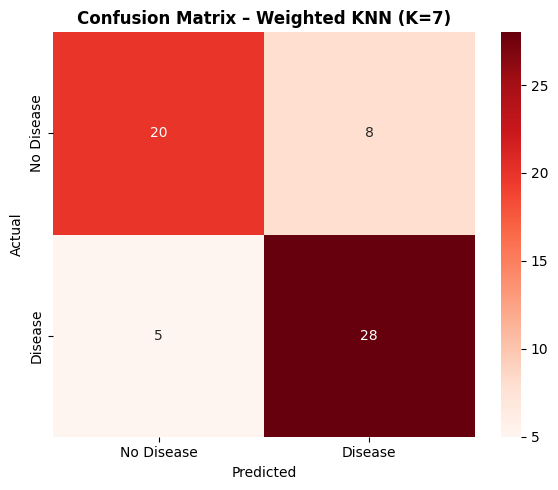

In [108]:
# CONFUSION MATRIX
cm_w = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix – Weighted KNN (K={best_k_distance})', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("WeightedKNN_ConfusionMatrix.png", dpi=300, bbox_inches='tight')
plt.show()


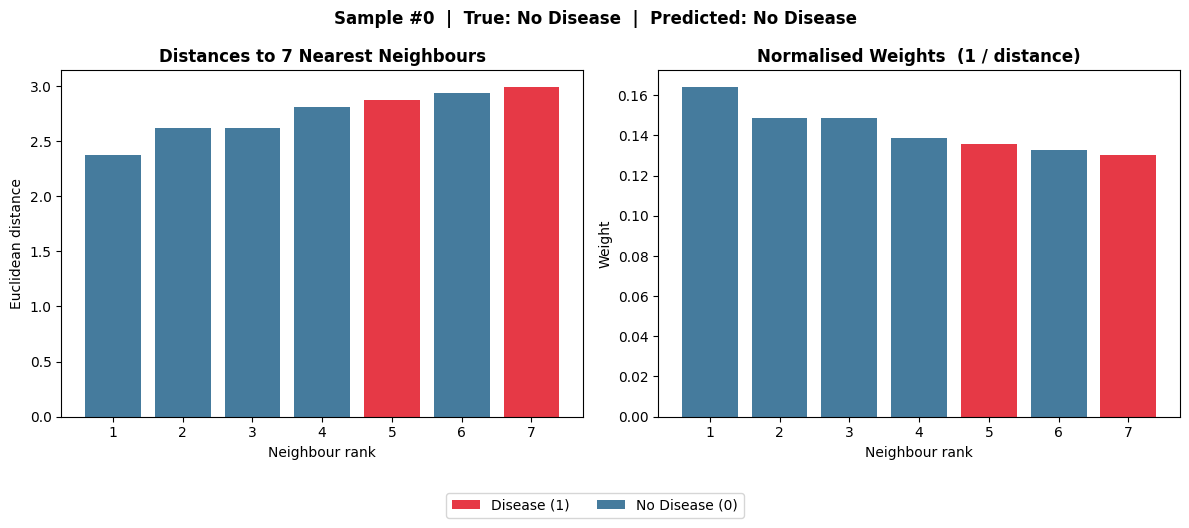

In [109]:
#  WEIGHT VISUALISATION: How distance weighting works
# Pick one test sample and show its K nearest neighbours + their weights

sample_idx  = 0
sample      = X_test_sc[[sample_idx]]

distances, indices = model_weighted.kneighbors(sample)
distances = distances[0]
indices   = indices[0]

weights   = 1.0 / distances                     # raw weights
weights  /= weights.sum()                        # normalise to sum=1

labels    = y_train.iloc[indices].values
colours   = ['#E63946' if l == 1 else '#457B9D' for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: distances
axes[0].bar(range(1, best_k_distance + 1), distances, color=colours)
axes[0].set_title(f'Distances to {best_k_distance} Nearest Neighbours', fontweight='bold')
axes[0].set_xlabel('Neighbour rank')
axes[0].set_ylabel('Euclidean distance')

# Right: normalised weights
axes[1].bar(range(1, best_k_distance + 1), weights, color=colours)
axes[1].set_title('Normalised Weights  (1 / distance)', fontweight='bold')
axes[1].set_xlabel('Neighbour rank')
axes[1].set_ylabel('Weight')

# shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E63946', label='Disease (1)'),
                   Patch(facecolor='#457B9D', label='No Disease (0)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)

pred_label = 'Disease' if model_weighted.predict(sample)[0] == 1 else 'No Disease'
true_label = 'Disease' if y_test.iloc[sample_idx] == 1 else 'No Disease'
fig.suptitle(f'Sample #{sample_idx}  |  True: {true_label}  |  Predicted: {pred_label}',
             fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("WeightedKNN_WeightVisualisation.png", dpi=300, bbox_inches='tight')
plt.show()
